# Example: Singular Value Decomposition of a Grayscale Image
What does the singular value decomposition reveal about the structure of a photograph? [Singular value decomposition (SVD)](https://en.wikipedia.org/wiki/Singular_value_decomposition) factors a matrix into an orthogonal matrix, a rectangular diagonal matrix of singular values, and another orthogonal matrix. It is used in many applications, such as image and data compression, signal processing, and machine learning.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * __Decompose a grayscale image with the SVD:__ A grayscale image is a matrix of pixel brightness values, so the SVD writes it as a weighted sum of rank-one frames. We'll compute the decomposition and check that its singular-vector matrices are orthogonal and that its factors multiply back to the image.
> * __Approximate the image from its first few frames:__ The frames come sorted from the largest singular value to the smallest. We'll measure the relative error of the image built from the first few frames and look at the rebuilt photograph.
> * __Relate the rank to the number of frames:__ Each frame is a rank-one matrix built from one pair of singular vectors. We'll check that the sum of the first few frames has rank equal to the number of frames added.

In this example, we apply the SVD from [the L7a lecture](CHEME-5800-L7a-Lecture-SVDAndDataReduction-Fall-2026.ipynb) to a photograph. The lecture's Eckart–Young theorem says that keeping only the largest singular values gives the closest approximation of a given rank, measured by the total squared error; here, we measure how close that approximation is for a real image. Let's get started!
___

## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines this folder's path, and loads the packages used here.

Let's set up our code environment:

In [1]:
# Load packages and paths -
include(joinpath(@__DIR__, "Include.jl")); # @__DIR__ locates this notebook's setup file

# Choose the plot appearance -
# After changing the theme, rerun this cell and the plotting cells.
theme(:default)   # light background
# theme(:dark)   # dark background

The setup also loads [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl); see [its documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) and the [Julia documentation](https://docs.julialang.org/en/v1/) for more information on the functions and types used in this material.

### Data
The [TestImages.jl package](https://github.com/JuliaImages/TestImages.jl) provides a convenient Julia interface for loading [standard named test images](https://en.wikipedia.org/wiki/Standard_test_image) and various other example images. We'll use the `lake_gray` image, a $512\times{512}$ grayscale photograph of a sailboat on a lake. Let's load this image and use SVD to decompose it into frames.

> __Grayscale images__ are arrays of pixel brightness values $0.0\leq{a_{ij}}\leq{1.0}$, where $a_{ij}$ is the pixel in row $i$ and column $j$. A value of `0.0` represents black, and `1.0` means white. Because an image is a matrix, we can use the SVD to factor it into components and look at the information each component holds.

Let's load the `lake_gray` image using [the `testimage(...)` function](https://testimages.juliaimages.org/stable/) and save it in the `img` variable. The first call downloads the image, so it needs an internet connection:

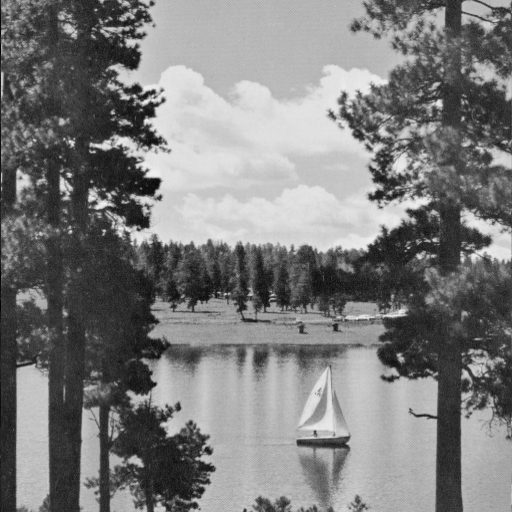

In [2]:
img = testimage("lake_gray") # load the sailboat image (downloads on first use)

The pixels load as `GrayA` values, a gray level with an alpha (transparency) channel. Next, let's convert them into an array of `Float64` numbers using [the `convert(...)` function](https://docs.julialang.org/en/v1/base/base/#Base.convert) in the Julia standard library.

> __Strange syntax alert!__ We use the `convert.` syntax to apply the conversion to every image element (similar to using `Gray.` to convert to grayscale). This is called a [vectorized dot operation](https://docs.julialang.org/en/v1/manual/mathematical-operations/#man-dot-operators) that applies a transformation to each element of the array. It's a shortcut instead of writing a loop.

We save the grayscale image matrix in the `image_array` variable.

In [3]:
image_array = convert.(Float64, Gray.(img)) # convert the image to an array of floats

512×512 Matrix{Float64}:
 0.145098   0.501961  0.509804  0.458824  …  0.72549   0.709804  0.588235
 0.141176   0.478431  0.513725  0.494118     0.737255  0.713725  0.490196
 0.145098   0.396078  0.411765  0.486275     0.698039  0.65098   0.356863
 0.145098   0.439216  0.396078  0.501961     0.682353  0.517647  0.333333
 0.133333   0.392157  0.396078  0.458824     0.654902  0.47451   0.270588
 0.133333   0.427451  0.423529  0.462745  …  0.686275  0.513725  0.282353
 0.133333   0.454902  0.521569  0.568627     0.623529  0.537255  0.309804
 0.129412   0.537255  0.6       0.666667     0.45098   0.45098   0.27451
 0.0862745  0.619608  0.686275  0.670588     0.392157  0.462745  0.384314
 0.0784314  0.494118  0.607843  0.623529     0.352941  0.501961  0.380392
 0.0705882  0.415686  0.564706  0.65098   …  0.25098   0.309804  0.34902
 0.0627451  0.372549  0.505882  0.6          0.192157  0.215686  0.470588
 0.0823529  0.352941  0.32549   0.431373     0.203922  0.231373  0.509804
 ⋮             

We now have the `image_array::Array{Float64,2}` matrix, which represents the grayscale values of the image. Each element in the matrix corresponds to a pixel in the image, with values ranging from `0.0` (black) to `1.0` (white).

___

## Task 1: Decompose the image using SVD
In this task, we compute the singular value decomposition (SVD) of the image matrix and check its properties.

> __How?__ We'll use [the `svd(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.SVD) from the LinearAlgebra package to compute the singular value decomposition of `image_array::Array{Float64,2}`. We could have written this ourselves, but it's convenient to use the built-in function.

This produces the `U`, `Σ`, and `V` matrices, holding the left singular vectors, the singular values, and the right singular vectors, respectively.

In [4]:
(U,Σ,V) = svd(image_array); # compute the SVD of the image

In [5]:
Σ

512-element Vector{Float64}:
 268.10765455123396
  51.81047313371455
  27.922033497053405
  21.077019969395
  20.225813526169112
  18.066512582621517
  17.948863651743405
  16.556236541958878
  13.050646438711851
  12.705927159112292
  11.83615411033817
  10.970597132972351
  10.66527571689995
   ⋮
   0.010273698700164612
   0.00912069099580869
   0.008567793553194567
   0.00762592499560811
   0.006498089190281429
   0.005767725452770498
   0.004939169469472656
   0.004383565976603444
   0.0031153742422123784
   0.0019494488308957809
   0.0010947152775380477
   0.0006404668846328464

### Check: Orthogonal factors and reconstruction
Let's check some of the properties of the matrices produced by the SVD. First, `U` and `V` are orthogonal matrices.

> __Test:__ The columns of `U` are orthogonal unit vectors, and so are the columns of `V`. 
> Thus, $\mathbf{U}^\top \mathbf{U} = \mathbf{I}$ and $\mathbf{V}^\top \mathbf{V} = \mathbf{I}$, where $\mathbf{I}$ is the identity matrix, i.e., the dot product of any pair of different columns is zero, and the dot product of each column with itself is one.

In the code block below, we compute the products and check if they are (approximately) equal to the identity matrix using [the `@assert` macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert) in the Julia standard library. If the assertion fails, [an `AssertionError`](https://docs.julialang.org/en/v1/base/base/#Core.AssertionError) will be raised.

This code compares each product with [the `I` constant](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.I) from the LinearAlgebra package, which stands for an identity matrix of whatever size the comparison needs.

In [6]:
let

    # compute the product -
    P₁ = transpose(U) * U;
    P₂ = transpose(V) * V;

    # check: both P₁ and P₂ should be identity matrices
    @assert isapprox(P₁, I) && isapprox(P₂, I)
end

Next, `Σ` should be a matrix with sorted values (largest to smallest). Is that what we see? Hmmm. Not quite. By default, [the `svd(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.SVD) returns the singular values as a __sorted vector__, not a diagonal matrix.

We can use [the `diagm(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.diagm) to generate a diagonal matrix `ΣM` from the `Σ` vector. This is the matrix $\mathbf{S}$ from the lecture.

In [7]:
ΣM = Σ |> m-> diagm(m) # convert the Σ vector to a diagonal matrix

512×512 Matrix{Float64}:
 268.108   0.0      0.0     0.0    …  0.0         0.0         0.0
   0.0    51.8105   0.0     0.0       0.0         0.0         0.0
   0.0     0.0     27.922   0.0       0.0         0.0         0.0
   0.0     0.0      0.0    21.077     0.0         0.0         0.0
   0.0     0.0      0.0     0.0       0.0         0.0         0.0
   0.0     0.0      0.0     0.0    …  0.0         0.0         0.0
   0.0     0.0      0.0     0.0       0.0         0.0         0.0
   0.0     0.0      0.0     0.0       0.0         0.0         0.0
   0.0     0.0      0.0     0.0       0.0         0.0         0.0
   0.0     0.0      0.0     0.0       0.0         0.0         0.0
   0.0     0.0      0.0     0.0    …  0.0         0.0         0.0
   0.0     0.0      0.0     0.0       0.0         0.0         0.0
   0.0     0.0      0.0     0.0       0.0         0.0         0.0
   ⋮                               ⋱              ⋮           
   0.0     0.0      0.0     0.0    …  0.0         0.0 

If we compute the matrix product $\mathbf{U}\mathbf{S}\mathbf{V}^\top$, we should get back our original image matrix (approximately, due to numerical precision issues). Let's check this.

In [8]:
let
    reconstructed = U * ΣM * transpose(V);
    @assert isapprox(reconstructed, image_array)
end

Ok, so our decomposition seems to be correct. Let's move on to the next task. 
___

## Task 2: Compute the frames and store them in a dictionary
In this task, we compute the frames of the image, store them in a dictionary, and measure how well the first few frames rebuild the image. 

> __Data reduction__
>
> Singular value decomposition (SVD) can be thought of as decomposing a matrix into a weighted, ordered sum of separable matrices, e.g., frames of a larger image. Let $\mathbf{A}\in\mathbb{R}^{m\times{n}}$ have the singular value decomposition $\mathbf{A} = \mathbf{U}\mathbf{S}\mathbf{V}^{\top}$. Then, the matrix $\mathbf{A}$ can be written as:
>
> $$
> \begin{align*}
> \mathbf{A} &= \sum_{i=1}^{r({\mathbf{A}})}\sigma_{i}\cdot\underbrace{\left(\mathbf{u}_{i}\otimes\mathbf{v}_{i}\right)}_{\mathbf{A}_{i}}
> \end{align*}
> $$
> where $r({\mathbf{A}})$ is the rank of matrix $\mathbf{A}$, the vectors $\mathbf{u}_{i}$ and $\mathbf{v}_{i}$ are the $i$-th left and right singular vectors, and $\sigma_{i}$ are the ordered singular values. The [outer product](https://en.wikipedia.org/wiki/Outer_product) $\mathbf{A}_{i} = \left(\mathbf{u}_{i}\otimes\mathbf{v}_{i}\right)$ is a separable rank-one component of the matrix $\mathbf{A}$.

Ok, so let's do this decomposition and see what this sum looks like. First, we compute the rank $r(\mathbf{A})$ of `image_array` using [the `rank(...)` function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.rank). The rank is the number of non-zero singular values in the SVD (numerically, the number above a small tolerance):

In [9]:
R = rank(image_array)

512

Next, we calculate the individual frames $\sigma_{i}\,\mathbf{A}_{i}$ of the image by computing the [outer product](https://en.wikipedia.org/wiki/Outer_product) of the left and right singular vectors.

We use [the `foreach(...)` function](https://docs.julialang.org/en/v1/base/collections/#Base.foreach) as a shortcut means of populating the `image_frames_dictionary` variable. We could have used a regular for loop. But let's go crazy!

In [10]:
image_frames_dictionary = let

    # initialize -
    image_frames_dictionary = Dict{Int64,Matrix{Gray{Float64}}}();

    R = rank(image_array); # how many frames will we have?
    foreach(i -> image_frames_dictionary[i] = Σ[i]*⊗(U[:,i],V[:,i]), 1:R); # another iteration pattern???

    image_frames_dictionary; # return
end

Dict{Int64, Matrix{Gray{Float64}}} with 512 entries:
  56  => [0.00146433 0.000268633 … 0.00620922 0.0067289; -0.000937664 -0.000172…
  35  => [0.00544824 0.0941816 … -0.010173 0.00434914; 0.00455488 0.0787383 … -…
  425 => [7.09436e-6 -2.13339e-5 … -3.84133e-5 1.17366e-5; 1.33316e-5 -4.00904e…
  429 => [-2.30386e-5 -1.51501e-5 … -8.91128e-6 5.38801e-5; 2.50756e-5 1.64897e…
  60  => [-0.00215342 -0.00752688 … 0.00146888 -0.0209274; -0.00174363 -0.00609…
  220 => [0.000952013 -3.30509e-6 … -0.00027953 -0.000712395; 0.00114276 -3.967…
  308 => [0.000297533 0.000672352 … 0.000617104 -0.0011678; -7.11045e-5 -0.0001…
  67  => [0.00714474 -0.0410458 … 0.0203699 0.0249557; 0.00742641 -0.0426639 … …
  215 => [-0.000465002 2.12365e-5 … 0.000328727 -6.58782e-5; 0.00182461 -8.3329…
  73  => [0.0039525 0.0117602 … 0.00283073 0.0044022; 0.00339485 0.010101 … 0.0…
  319 => [-1.83005e-5 2.86602e-5 … 0.000169633 -8.72264e-5; -4.59417e-5 7.19489…
  251 => [-6.39536e-5 -9.08434e-5 … -0.000110712 3.04505

### Not every frame contains the same amount of information
One of the cool things about [singular value decomposition](https://en.wikipedia.org/wiki/Singular_value_decomposition) is that frames are sorted and weighted by the singular values. Thus, we can compute the contribution of each frame by looking at the singular values.

Let's compute and visualize how close the image built from the first $k$ frames, $\hat{\mathbf{A}}_{k}=\sum_{i=1}^{k}\sigma_{i}\mathbf{A}_{i}$, is to the original image $\mathbf{A}$. We measure the gap with the [Frobenius norm](https://en.wikipedia.org/wiki/Matrix_norm#Frobenius_norm): we square the pixel-by-pixel differences, add them up, and take the square root.

Each frame $i$ contributes $\sigma_{i}^{2}$ to the squared Frobenius norm of the image, $\|\mathbf{A}\|_{F}^{2}=\sum_{i}\sigma_{i}^{2}$. Thus, the relative error of $\hat{\mathbf{A}}_{k}$ comes from the singular values of the frames we left out:

$$
e_{k} = \frac{\|\mathbf{A}-\hat{\mathbf{A}}_{k}\|_{F}}{\|\mathbf{A}\|_{F}} = \sqrt{\frac{\sum_{i=k+1}^{r(\mathbf{A})}\sigma_{i}^{2}}{\sum_{i=1}^{r(\mathbf{A})}\sigma_{i}^{2}}}
$$

Let's plot $e_{k}$ for the first 100 frames:

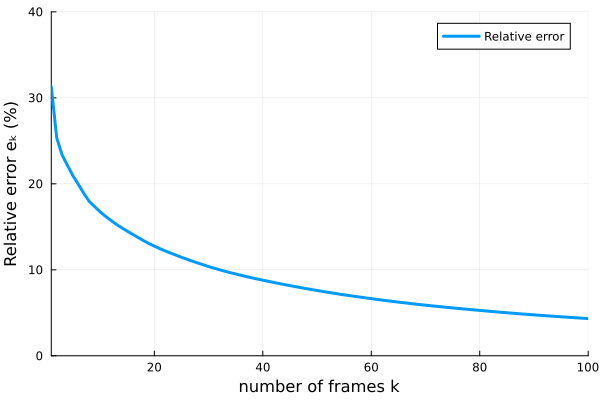

In [11]:
let
    
    # make a plot of the relative error of the image built from the first k frames
    total_frames = length(Σ); # one frame per singular value
    ΣS = (1/sum(Σ.^2))*(Σ.^2); # fraction of the squared Frobenius norm carried by each frame
    error_array = [100*sqrt(sum(ΣS[(k+1):end])) for k ∈ 1:total_frames]; # comprehension, sums over the frames we left out

    plot(error_array, label="Relative error", lw=3)
    xlabel!("number of frames k", fontsize=18)
    ylabel!("Relative error eₖ (%)", fontsize=18)
    xlims!(1, 100) # show the first 100 frames
    ylims!(0, 40) # start the error axis at zero
end

With no frames the error is 100%, and one frame already brings it down to about 31%. We did not subtract the average pixel value before the SVD, so the first frame mostly holds the image's average brightness. The later frames add edges and finer detail: 10 frames give about 17% error, 20 frames give about 13%, and 100 frames give about 4%. We add up the frames and look at the rebuilt image in Task 3.

___

## Task 3: Approximate the image from its first few frames
In this task, we add up the first few frames to approximate the image, and then check the rank of the result.

### Can we rebuild the image from its first few frames?
Let's try to rebuild the original image by adding up the frames. Since the image is just a matrix, it equals the sum of all of its frames, as in the Data reduction box in Task 2.

> __Idea:__ Grab the first frame from the `image_frames_dictionary` and set this to the `M` variable. Then, iterate through the collection up to a specified `number_of_frames`, where we update the `M` variable each time through the loop with the next frame. This should approximate the original image, one rank unit at a time. Mind blown!

So what do we see?

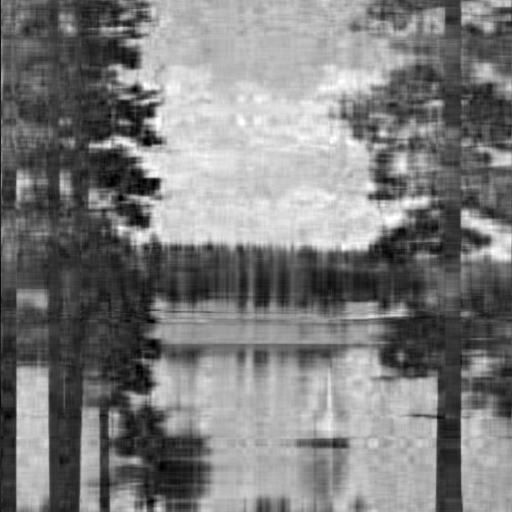

In [12]:
# initialize -
M = image_frames_dictionary[1]; # start from the first frame
number_of_frames = 20; # how many frames to add up

# main loop -
for i ∈ 2:number_of_frames
    M += image_frames_dictionary[i] # add the next frame
end
M # this will show the reconstructed image

With 20 frames, the trees and the shoreline are easy to recognize, but the sailboat is only a faint smudge, the clouds blur together, and the water shows horizontal and vertical streaks. The error plot in Task 2 puts this image at about 13% relative error. If you change `number_of_frames`, your image and error will change too; by about 50 frames, the sailboat is easy to make out.

### What is the rank of the rebuilt image?
Recall that the rank of a matrix is the number of linearly independent rows (or columns) in a matrix. Singular value decomposition gives us another way to think about rank: it is a measure of the unique information held by the matrix, i.e., the number of rank-one frames in the sum!

> __Idea.__ Let's check out this alternative notion of rank. If we reconstruct the matrix by adding frames together, the rank of the resulting matrix will be equal to the number of frames being added, i.e., the `number_of_frames` variable that we specified. This works because the left singular vectors of the frames are orthogonal to each other, and so are the right singular vectors.

Let's compute the rank of the `M` matrix and check it using [the `@assert` macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert):

In [13]:
@assert rank(M) == number_of_frames

Wow!
___

## Summary

In this example, we factored a grayscale photograph with the SVD, measured how well its first few frames rebuild it, and checked the rank of their sum.

> __Key Takeaways:__
>
> * __The SVD splits an image into ranked frames:__ We factored the image matrix into left singular vectors, singular values, and right singular vectors, and checked that multiplying them back together returns the image. Each singular value weights one rank-one frame, and the frames come sorted from largest to smallest weight.
> * __A few frames rebuild a recognizable image:__ We measured the relative error of the image built from the first few frames and found that it falls quickly and then levels off. With 20 of the 512 frames, the error is about 13%, and the trees and shoreline are easy to recognize while the sailboat is still a blur.
> * __The number of frames sets the rank:__ We added up the first few frames and checked that the rank of the sum equals the number of frames. This works because the singular vectors of different frames are orthogonal, so each new frame raises the rank by one.

Change `number_of_frames` in Task 3 to see how the rebuilt image changes. In [the L7b lab](../L7b/CHEME-5800-L7b-Lab-SVD-StoichiometricMatrix-Fall-2026.ipynb), we apply the same decomposition to a metabolic stoichiometric matrix.

___